In [1]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

In [2]:
# Download required NLTK data (run once)
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

### 1. BASIC TEXT AND TOKENIZATION

In [3]:
sample_text = """
Natural language processing (NLP) is a subfield of linguistics, computer science,
and artificial intelligence concerned with the interactions between computers and
human language. NLP is used to apply machine learning algorithms to text and speech.
"""

print("=" * 70)
print("1. TOKENIZATION")
print("=" * 70)

# Sentence tokenization
sentences = sent_tokenize(sample_text)
print(f"\nNumber of sentences: {len(sentences)}")
print(f"First sentence: {sentences[0]}")

# Word tokenization
words = word_tokenize(sample_text.lower())
print(f"\nNumber of words: {len(words)}")
print(f"First 20 tokens: {words[:20]}")

1. TOKENIZATION

Number of sentences: 2
First sentence: 
Natural language processing (NLP) is a subfield of linguistics, computer science,
and artificial intelligence concerned with the interactions between computers and
human language.

Number of words: 41
First 20 tokens: ['natural', 'language', 'processing', '(', 'nlp', ')', 'is', 'a', 'subfield', 'of', 'linguistics', ',', 'computer', 'science', ',', 'and', 'artificial', 'intelligence', 'concerned', 'with']


### 2. STOP WORDS

In [4]:
print("\n" + "=" * 70)
print("2. STOP WORDS REMOVAL")
print("=" * 70)

stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

print(f"\nOriginal word count: {len(words)}")
print(f"Stop word count whole corpus: {len(list(stop_words))}")
print(f"Filtered word count: {len(filtered_words)}")
print(f"Sample stop words: {list(stop_words)[:10]}")
print(f"Filtered words: {filtered_words[:20]}")


2. STOP WORDS REMOVAL

Original word count: 41
Stop word count whole corpus: 198
Filtered word count: 23
Sample stop words: ["i've", 'll', 'for', 'him', 'above', 'aren', 'but', 'did', "we're", 'why']
Filtered words: ['natural', 'language', 'processing', 'nlp', 'subfield', 'linguistics', 'computer', 'science', 'artificial', 'intelligence', 'concerned', 'interactions', 'computers', 'human', 'language', 'nlp', 'used', 'apply', 'machine', 'learning']


### 3. STEMMING VS LEMMATIZATION

In [5]:
print("\n" + "=" * 70)
print("3. STEMMING vs LEMMATIZATION")
print("=" * 70)

# test_words = ['running', 'runs', 'ran', 'easily', 'fairly', 'processing', 'processed']
test_words = filtered_words

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

print("\n{:<15} {:<15} {:<15}".format("Original", "Stemmed", "Lemmatized"))
print("-" * 45)
for word in test_words:
    stem = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word)
    print("{:<15} {:<15} {:<15}".format(word, stem, lemma))


3. STEMMING vs LEMMATIZATION

Original        Stemmed         Lemmatized     
---------------------------------------------
natural         natur           natural        
language        languag         language       
processing      process         processing     
nlp             nlp             nlp            
subfield        subfield        subfield       
linguistics     linguist        linguistics    
computer        comput          computer       
science         scienc          science        
artificial      artifici        artificial     
intelligence    intellig        intelligence   
concerned       concern         concerned      
interactions    interact        interaction    
computers       comput          computer       
human           human           human          
language        languag         language       
nlp             nlp             nlp            
used            use             used           
apply           appli           apply          
machine    

### 4. PART-OF-SPEECH (POS) TAGGING

In [6]:
print("\n" + "=" * 70)
print("4. PART-OF-SPEECH (POS) TAGGING")
print("=" * 70)

sentence = "NLTK is a powerful library for natural language processing."
tokens = word_tokenize(sentence)
pos_tags = pos_tag(tokens)

print(f"\nTokens with POS tags:")
print("{:<15} {:<10}".format("Token", "POS"))
print("-" * 25)
for token, pos in pos_tags:
    print("{:<15} {:<10}".format(token, pos))


4. PART-OF-SPEECH (POS) TAGGING

Tokens with POS tags:
Token           POS       
-------------------------
NLTK            NNP       
is              VBZ       
a               DT        
powerful        JJ        
library         NN        
for             IN        
natural         JJ        
language        NN        
processing      NN        
.               .         


### 5. NAMED ENTITY RECOGNITION (NER)

In [7]:
print("\n" + "=" * 70)
print("5. NAMED ENTITY RECOGNITION (NER)")
print("=" * 70)

sentence_ner = "Apple Inc. was founded by Steve Jobs in California."
tokens_ner = word_tokenize(sentence_ner)
pos_tags_ner = pos_tag(tokens_ner)
ne_tree = ne_chunk(pos_tags_ner)

# print(f"\nNER Tree:")
# print(ne_tree)
print(f"\nNamed Entities:")
for subtree in ne_tree:
    if hasattr(subtree, 'label'):
        print(f"  {' '.join(word for word, tag in subtree.leaves())} ({subtree.label()})")



5. NAMED ENTITY RECOGNITION (NER)

Named Entities:
  Apple (PERSON)
  Inc. (ORGANIZATION)
  Steve Jobs (PERSON)
  California (GPE)


### 6. FREQUENCY DISTRIBUTION

In [8]:
print("\n" + "=" * 70)
print("6. FREQUENCY DISTRIBUTION")
print("=" * 70)

# Use a larger corpus for meaningful frequency analysis
extended_text = sample_text.lower()
extended_words = word_tokenize(extended_text)
extended_filtered = [w for w in extended_words if w.isalnum() and w not in stop_words]

freq_dist = FreqDist(extended_filtered)
print(f"\nMost common words:")
print(freq_dist.most_common(10))


6. FREQUENCY DISTRIBUTION

Most common words:
[('language', 2), ('nlp', 2), ('natural', 1), ('processing', 1), ('subfield', 1), ('linguistics', 1), ('computer', 1), ('science', 1), ('artificial', 1), ('intelligence', 1)]


### 7. VISUALIZATION


7. VISUALIZATION


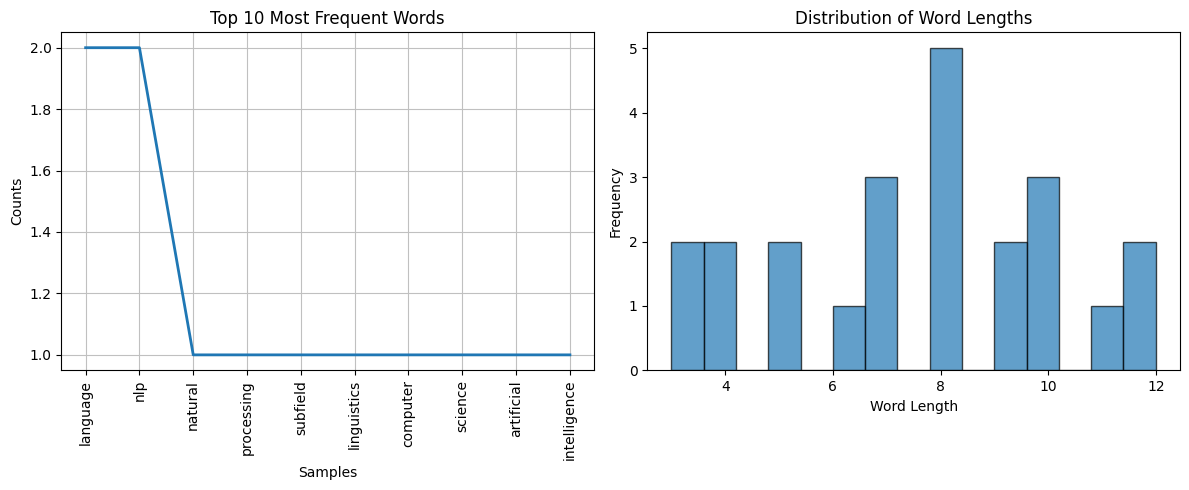

In [9]:
print("\n" + "=" * 70)
print("7. VISUALIZATION")
print("=" * 70)

plt.figure(figsize=(12, 5))

# Plot 1: Frequency distribution
plt.subplot(1, 2, 1)
freq_dist.plot(10, title="Top 10 Most Frequent Words")

# Plot 2: Word length distribution
word_lengths = [len(w) for w in extended_filtered]
plt.subplot(1, 2, 2)
plt.hist(word_lengths, bins=15, edgecolor='black', alpha=0.7)
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Distribution of Word Lengths')
plt.tight_layout()
plt.show()

### 8. CONCORDANCE AND SIMILAR WORDS

In [10]:
print("\n" + "=" * 70)
print("8. CONCORDANCE ANALYSIS")
print("=" * 70)

from nltk.text import Text

nltk_text = Text(extended_filtered)
print("\nConcordance for 'language':")
nltk_text.concordance('language', width=79, lines=3)

print("\nSimilar words to 'language':")
nltk_text.similar('language')


8. CONCORDANCE ANALYSIS

Concordance for 'language':
Displaying 2 of 2 matches:
                           natural language processing nlp subfield linguistic
erned interactions computers human language nlp used apply machine learning al

Similar words to 'language':



### 9. VOCABULARY AND LEXICAL DIVERSITY

In [11]:
print("\n" + "=" * 70)
print("9. VOCABULARY STATISTICS")
print("=" * 70)

total_words = len(extended_filtered)
unique_words = len(set(extended_filtered))
lexical_diversity = unique_words / total_words if total_words > 0 else 0

print(f"\nTotal words: {total_words}")
print(f"Unique words: {unique_words}")
print(f"Lexical diversity (type-token ratio): {lexical_diversity:.4f}")



9. VOCABULARY STATISTICS

Total words: 23
Unique words: 21
Lexical diversity (type-token ratio): 0.9130


### 10. SUMMARY DATAFRAME

In [12]:
print("\n" + "=" * 70)
print("10. SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame({
    'Metric': ['Total Words', 'Unique Words', 'Lexical Diversity', 'Average Word Length'],
    'Value': [total_words, unique_words, f"{lexical_diversity:.4f}", f"{sum(word_lengths)/len(word_lengths):.2f}"]
})

print("\n", summary_df.to_string(index=False))


10. SUMMARY

              Metric  Value
        Total Words     23
       Unique Words     21
  Lexical Diversity 0.9130
Average Word Length   7.57
